In [1]:
# header for current kernel
from pyCHX.chx_packages import *
plt.rcParams.update({'figure.max_open_warning': 0})
plt.rcParams.update({ 'image.origin': 'lower'   })
plt.rcParams.update({ 'image.interpolation': 'none'   })
import matplotlib.patches as mpatches
from copy import deepcopy


import pyFAI
from pyFAI import geometryRefinement
from pyFAI.method_registry import Method,IntegrationMethod

import re
import cv2
from pathvalidate import sanitize_filename

import sys
sys.path.insert(0, "/nsls2/data/chx/shared/CHX_Software/packages/standard_functions/")
from standard_functions import *

%run /nsls2/data/chx/shared/CHX_Software/packages/environment_management/chx_analysis_setup_test_pyCHX.ipynb

Tiled version 0.1.0a120
/nsls2/conda/envs/2024-2.0-py311-tiled/lib/python3.11/site-packages/databroker/v1.py:72: UserWarning: In databroker 2.x, there are separate notions of 'server' and 'client', and register_handler(...) has no effect on the client. Likely this is being done for you on the server side, so you should not worry about this message unless you encounter trouble loading large array data.
  warnings.warn(


running on: jupyter_hub   environment: standard

setting '_base_path_' as /nsls2/data/chx/legacy/analysis/
setting '_mask_path_' as /nsls2/data/chx/shared/CHX_Setup/Detector_masks/



Tiled version 0.1.0a120
INFO:tiled.server.app:Tiled version 0.1.0a120
/nsls2/conda/envs/2024-2.0-py311-tiled/lib/python3.11/site-packages/databroker/v1.py:72: UserWarning: In databroker 2.x, there are separate notions of 'server' and 'client', and register_handler(...) has no effect on the client. Likely this is being done for you on the server side, so you should not worry about this message unless you encounter trouble loading large array data.
  warnings.warn(


Re-imported pyCHX from /nsls2/data/chx/shared/CHX_Software/packages/pyCHX/
Re-imported chx_compress from /nsls2/data/chx/shared/CHX_Software/packages/pyCHX/chx_compress.py

environment dependent settings and patches:
using "%matplotlib inline" for plotting


### Specify dataset to load

In [2]:
user = 'cai'
cycle = '2024_3'

# silver behenate colibration (list should contain only one scan_id or uid)
#calibration =  157601 # WAXS detector position optimized for Rufina's and Stan's samples
#calibration =  157615 # WAXS detector position optimized for PP 3D printing
calibration =159929 #WAXS detector at ~140mm

scan_list =  [160095] # list, but only takes one entry at a time for now
result_dir = '%s%s/%s/%s/'%(_base_path_,cycle,user,'Results')

###############################################################################################################
(tmp,c_uid)=get_uid_list([calibration],user=user,cycle=cycle,uid_length=8,verbose=True)
cfilepath=result_dir+'Pilatus_800k_calibration_uid_%s.pkl'%c_uid[0]
print('loading calibration data from: ',cfilepath)
(scan_list,uid_list)=get_uid_list(scan_list,user=user,cycle=cycle,uid_length=8,verbose=True)

process_dict = {'md':{'uid':db[uid_list[0]].start['uid'],'scan_id':scan_list[0],'user':user,'cycle':cycle,'result_dir':result_dir},'2D_all_average':{},'2D_range_average':{},'1D_all':{'data':{},'units':{}},'1D_all_average':{'data':{},'units':{}},'1D_range':{'data':{},'units':{}},'1D_range_average':{'data':{},'units':{}},'phi_map':{},'processing':{}}

getting scan_ids/uids…: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  4.92it/s]

detailed information for all scan_ids:
uid list: 75a5f055  ->  scan list: 159929
loading calibration data from:  /nsls2/data/chx/legacy/analysis/2024_3/cai/Results/Pilatus_800k_calibration_uid_75a5f055.pkl
getting scan_ids/uids…: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  5.27it/s]

detailed information for all scan_ids:
uid list: dbbbdc75  ->  scan list: 160095


### Loading Calibration

In [3]:
config_dict=load_pickle(cfilepath,verbose=True)
process_dict['processing']['config_dict']=config_dict
print(config_dict.keys())

Loading data from file: /nsls2/data/chx/legacy/analysis/2024_3/cai/Results/Pilatus_800k_calibration_uid_75a5f055.pkl
dict_keys(['scan_id', 'uid', 'calibrant', 'detector', 'direct_beam_x', 'direct_beam_y', 'energy', 'geo_config'])


### Setting up pyFAI

In [4]:
detector = pyFAI.detector_factory(config_dict['detector'])
aintegrator=pyFAI.azimuthalIntegrator.AzimuthalIntegrator(dist=config_dict['geo_config']['dist'], poni1=config_dict['geo_config']['poni1'], poni2=config_dict['geo_config']['poni2'],
                                                          rot1=config_dict['geo_config']['rot1'], rot2=config_dict['geo_config']['rot2'], rot3=config_dict['geo_config']['rot3'], 
                                                          pixel1=None, pixel2=None, splineFile=None, detector=config_dict['geo_config']['detector'], wavelength=config_dict['geo_config']['wavelength'])
aintegrator

Detector Pilatus 1M	 PixelSize= 1.720e-04, 1.720e-04 m	 BottomRight (3)
Wavelength= 8.853817e-11 m
SampleDetDist= 1.439011e-01 m	PONI= 6.146592e-02, 1.216748e-01 m	rot1=0.000000  rot2=0.000000  rot3=0.000000 rad
DirectBeamDist= 143.901 mm	Center: x=707.412, y=357.360 pix	Tilt= 0.000° tiltPlanRotation= 0.000° 𝛌= 0.885Å

### Loading Data

In [5]:
h=db[uid_list[0]]
frame_time=h.start['pil800k_acquire_period']
# f=h.start['detectors'][0]+'_image' # this used to work but in 2024-3 data access became really terrible
# print(f)
# im=list(h.data(f))
# img = np.flipud(im[0][0])

t1=time.time()
frames = h.start['pil800k_imnum']
fn=list(h.v2.documents())[2][1]['root']+'/'+list(h.v2.documents())[2][1]['resource_path']+'/'+list(h.v2.documents())[2][1]['resource_kwargs']['filename']
fending = list(h.v2.documents())[2][1]['resource_kwargs']['template'].split('.')[-1]
fndigits = int(re.findall("\d+",list(h.v2.documents())[2][1]['resource_kwargs']['template'].split('.')[-2])[0])
frn_list=[]
for i in range(frames):
    frn_list.append(('00000000000'+str(i))[-fndigits:])
im=np.zeros((1,int(len(frn_list)),1043,981))
t2=time.time()
for ff,f in enumerate(frn_list):
    im[0,ff,:,:] = cv2.imread(fn+'_'+f+'.'+fending, cv2.IMREAD_UNCHANGED)
img_stack = np.flip(im[0],axis=1)
print(time.time()-t1,time.time()-t2)
img=img_stack[0,:,:]
for k in ['sample','Measurement','pil800k_acquire_period','pil800k_exposure_time','pil800k_imnum']:
    process_dict['md'][k]=h.start[k]

0.6191880702972412 0.5130271911621094


### create some masks

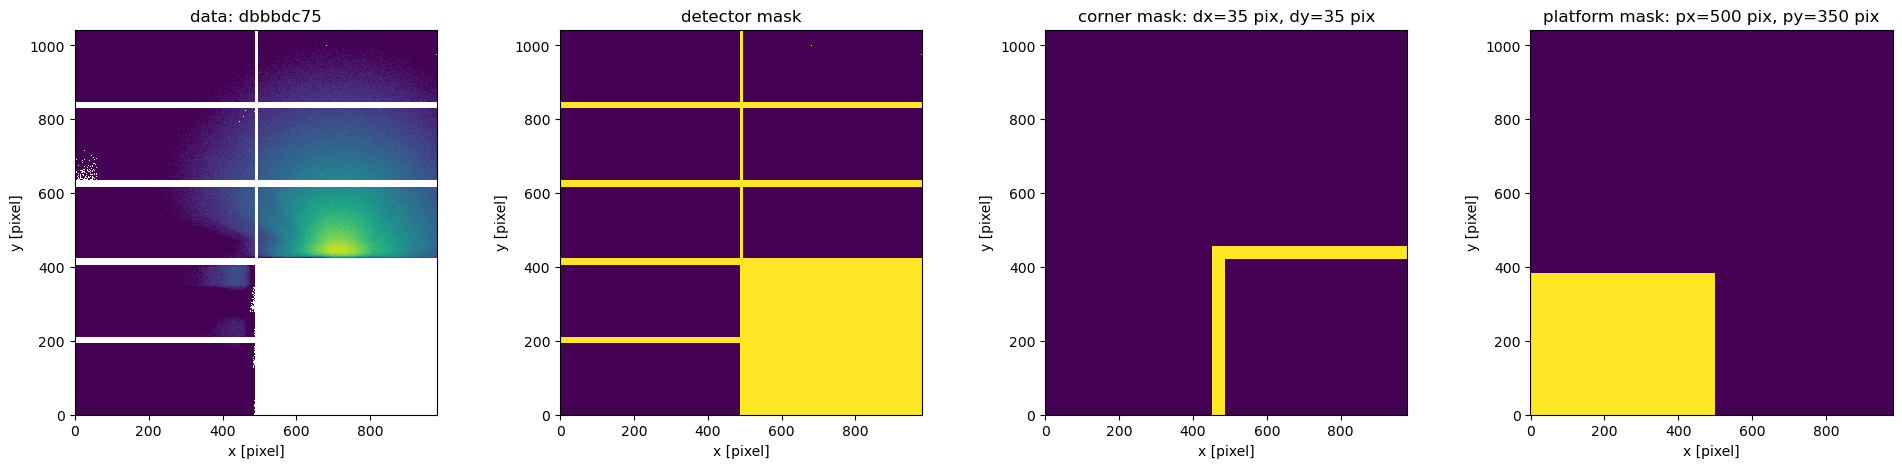

In [6]:
masks={}
corner_masking = True # mask stripe of pixels with widht dx,dy around detector cutout
dx=35
dy=35
if corner_masking:
    masks['corner_masking']={'dx':dx,'dy':dy}

platform_masking = True
px=500
py=350
if platform_masking:
    masks['platform_masking']={'px':px,'py':py}
process_dict['processing']['masking']=masks

fix,ax = plt.subplots(1,4,figsize=(24,5))
plt.subplot(1,4,1)
plt.imshow(img,norm='log',vmin=200,vmax=2000)
plt.title('data: %s'%uid_list[0]);plt.xlabel('x [pixel]');plt.ylabel('y [pixel]')

mask = np.zeros(np.shape(img))
m = img<0
mask[m]=1
plt.subplot(1,4,2)
plt.imshow(mask)
plt.title('detector mask');plt.xlabel('x [pixel]');plt.ylabel('y [pixel]')

plt.subplot(1,4,3)
corner_mask=np.zeros(np.shape(mask))
if corner_masking:
    corner_mask[0:423+dx,487-dx:487]=1
    corner_mask[423:423+dy,487-dx:]=1
    plt.imshow(corner_mask);plt.title('corner mask: dx=%s pix, dy=%s pix'%(dx,dy));plt.xlabel('x [pixel]');plt.ylabel('y [pixel]')

plt.subplot(1,4,4)
platform_mask=np.zeros(np.shape(mask))
if platform_masking:
    platform_mask[0:py+dx,0:px]=1
    plt.imshow(platform_mask);plt.title('platform mask: px=%s pix, py=%s pix'%(px,py));plt.xlabel('x [pixel]');plt.ylabel('y [pixel]')
mask_=mask+corner_mask+platform_mask
ind = mask_>0
img_mask=np.ones(np.shape(mask_));img_mask[ind]=0

### plotting Masked data

Text(0.5, 1.0, 'scan_id: 160095, uid: dbbbdc75\nsample: Sample6-NIPAM0-thick-4')

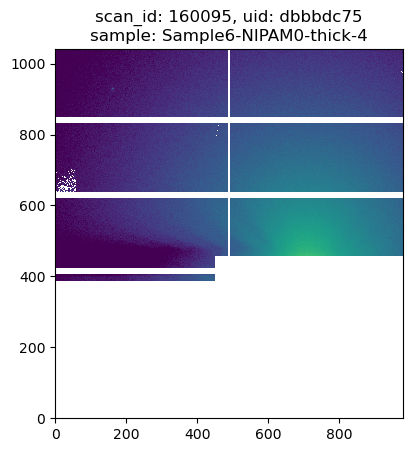

In [7]:
plt.imshow(img*img_mask,norm='log',vmin=100,vmax=5500)
plt.title('scan_id: %s, uid: %s\nsample: %s'%(scan_list[0],uid_list[0],h.start['sample']))

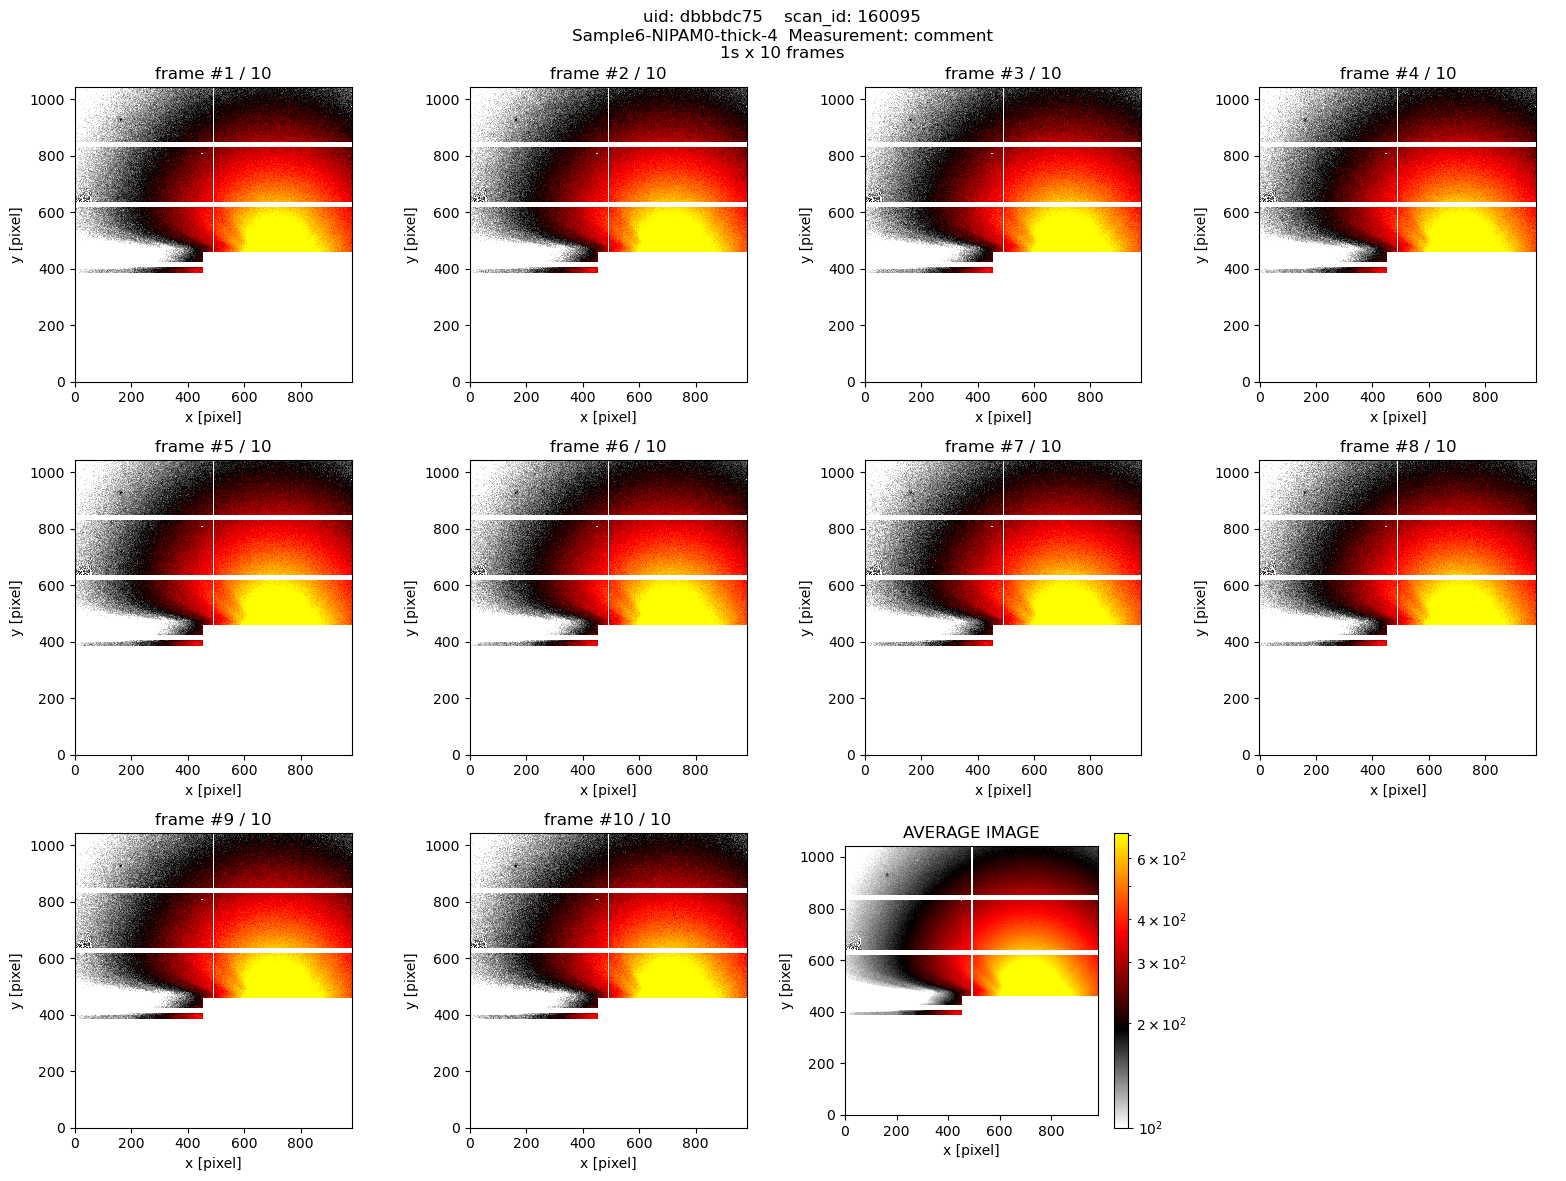

In [8]:
ave_img = np.nanmean(img_stack[:,:,:]*img_mask,axis=0)
try: #autoscale
    bins=np.linspace(1,np.max(ave_img),1000)
    hist = np.histogram(ave_img,bins)
    cs = np.cumsum(hist[0])
    vmax=hist[1][np.argmin(np.abs(cs-.95*np.max(cs)))]
    vmin=hist[1][np.argmin(np.abs(cs-.08*np.max(cs)))]
except: # manual scaling
    vmin=100
    vmax=1000

h=db[uid_list[0]]
nrows=4
ncols=int(np.ceil((1+np.shape(img_stack)[0])/nrows))
fix,ax = plt.subplots(ncols,nrows,figsize=(16,3*nrows));pc=1
plt.suptitle('uid: %s    scan_id: %s\n%s  Measurement: %s\n%ss x %s frames'%(uid_list[0],h.start['scan_id'],h.start['sample'],h.start['Measurement'],h.start['pil800k_exposure_time'],h.start['pil800k_imnum']))
for i in range(np.shape(img_stack)[0]):
    plt.subplot(ncols,nrows,pc);pc+=1
    plt.title('frame #%s / %s'%(i+1,h.start['pil800k_imnum']))    
    plt.imshow(img_stack[i,:,:]*img_mask,norm='log',cmap=cmap_albula,vmin=vmin, vmax=vmax)
    plt.xlabel('x [pixel]');plt.ylabel('y [pixel]')
plt.subplot(ncols,nrows,pc);pc+=1
plt.imshow(ave_img,norm='log',cmap=cmap_albula,vmin=vmin,vmax=vmax );plt.colorbar()
plt.title('AVERAGE IMAGE');plt.xlabel('x [pixel]');plt.ylabel('y [pixel]')
plt.tight_layout()
for i in range(nrows*ncols-pc+1):
    plt.subplot(ncols,nrows,pc);pc+=1
    ax=plt.gca();ax.set_axis_off()
process_dict['2D_all_average']={'img':ave_img,'x_unit':'x [pixel]','y_unit':'y [pixel]'}

### Radial Integration

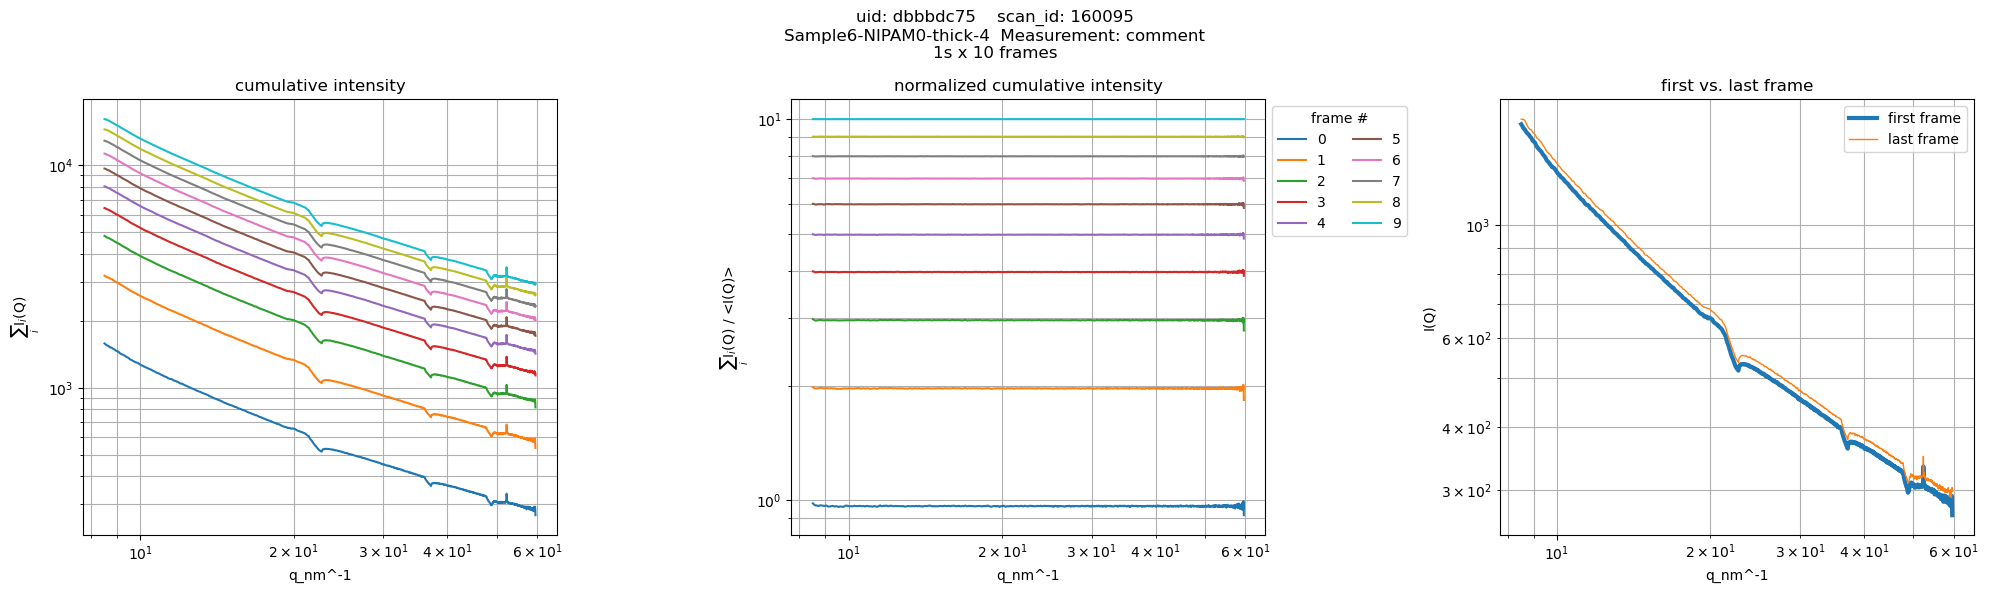

In [9]:
azi=[]
q_unit = "q_nm^-1"
process_dict['1D_all']['units']={'q':q_unit,'y':'I(Q)'}
process_dict['1D_all_average']['units']={'q':q_unit,'y':'I(Q)'}
for i in range(np.shape(img_stack)[0]):
    lab=None
    if np.shape(img_stack)[0] >1:
        lab = '%s'%i
    azi.append( aintegrator.integrate1d(img_stack[i,:,:],npt=1200,mask=mask_,unit=q_unit))
    process_dict['1D_all']['data'][i]={'q':azi[i][0],'iq_waxs':azi[i][1]}
azi_average = np.nanmean(azi,axis=0)
process_dict['1D_all_average']['data']={'q':azi_average[0],'iq_waxs':azi_average[1]}

fig,ax=plt.subplots(1,3,figsize=(20,6))
plt.suptitle('uid: %s    scan_id: %s\n%s  Measurement: %s\n%ss x %s frames'%(uid_list[0],h.start['scan_id'],h.start['sample'],h.start['Measurement'],h.start['pil800k_exposure_time'],h.start['pil800k_imnum']))
cumsum=np.zeros(np.shape(azi)[2])
for i in range(np.shape(azi)[0]):
    cumsum+=azi[i][1]
    plt.subplot(1,3,1)
    plt.loglog(azi[i][0],cumsum)
    
    plt.subplot(1,3,2)
    plt.loglog(azi[i][0],cumsum/azi_average[1],label='%s'%i)
plt.subplot(1,3,1)
plt.title('cumulative intensity')
plt.xlabel(q_unit);plt.grid(True,'both');plt.ylabel(r'$\sum_{i}$I$_i$(Q)')

plt.subplot(1,3,2)
plt.title('normalized cumulative intensity')
plt.xlabel(q_unit);plt.grid(True,'both');plt.ylabel(r'$\sum_{i}$I$_i$(Q) / <I(Q)>')
plt.legend(title='frame #',loc='upper left',bbox_to_anchor=(1,1),ncols=2)

# first vs. last frame
plt.subplot(1,3,3)
plt.title('first vs. last frame')
plt.loglog(azi[0][0],azi[0][1],linewidth=3,label='first frame')
plt.loglog(azi[-1][0],azi[-1][1],linewidth=1,label='last frame')
plt.xlabel(q_unit);plt.grid(True,'both');plt.ylabel('I(Q)');plt.legend(loc='best')

plt.tight_layout()

### If needed: specify frames to average -> recalculate average image and average radial integration

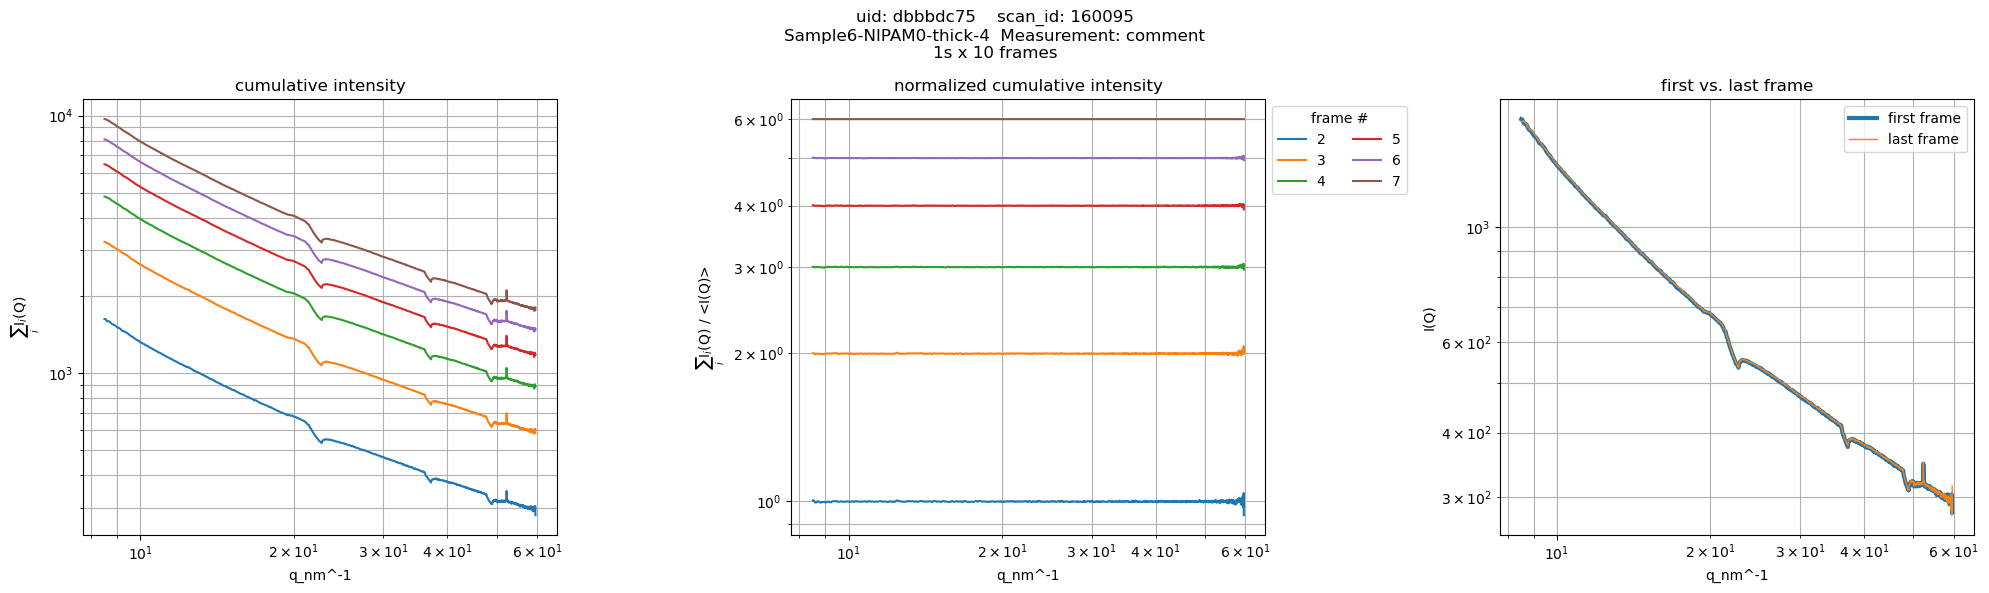

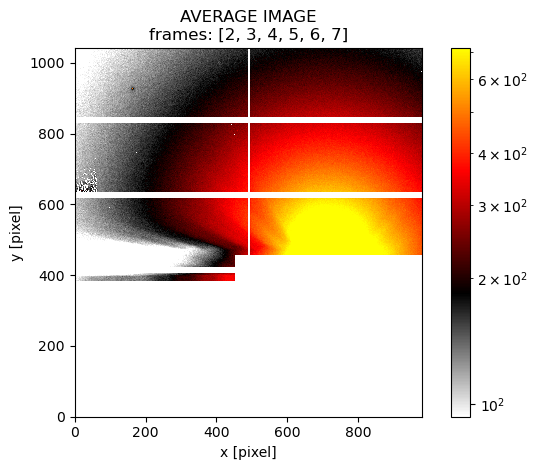

In [10]:
select_frame_range = True  ### =True to modify range, otherwise: =False
if select_frame_range:
    full_range=np.shape(azi)[0]-1
    
    ###### different ways to select a subset of frames for averaging (comment the ones you're NOT using), [NOTE: first frame is number 0 in python, so a series of 10 frames is 0-9]:
    frame_list= [2,4,7] # select individual frames
    frame_list = np.arange(2,8).tolist() # range of frames, NOTE: e.g. (2,8) is the half-open interval [2,8[ in python, i.e. it corresponds ot frames 2-7
    ############################################
    
    assert min(frame_list) >=0 and min(frame_list) < full_range and max(frame_list) < full_range, 'ERROR: selected frames need to be in the range 0 - %s'%full_range
    process_dict['processing']['frame_list']=frame_list
    
    azi_mod=[]
    #q_unit = "q_nm^-1" no need to change units when changing range of frames
    process_dict['1D_range']['units']={'q':q_unit,'y':'I(Q)'}
    process_dict['1D_range_average']['units']={'q':q_unit,'y':'I(Q)'}
    for i in frame_list:
        azi_mod.append( aintegrator.integrate1d(img_stack[i,:,:],npt=1200,mask=mask_,unit=q_unit))
        process_dict['1D_range']['data'][i]={'q':azi_mod[-1][0],'iq_waxs':azi_mod[-1][1]}
    azi_average_mod = np.nanmean(azi_mod,axis=0)
    process_dict['1D_range_average']['data']={'q':azi_average_mod[0],'iq_waxs':azi_average_mod[1]}
    
    
    fig,ax=plt.subplots(1,3,figsize=(20,6))
    plt.suptitle('uid: %s    scan_id: %s\n%s  Measurement: %s\n%ss x %s frames'%(uid_list[0],h.start['scan_id'],h.start['sample'],h.start['Measurement'],h.start['pil800k_exposure_time'],h.start['pil800k_imnum']))
    cumsum=np.zeros(np.shape(azi_mod)[2])
    for i,ii in enumerate(frame_list):
        cumsum+=azi_mod[i][1]
        plt.subplot(1,3,1)
        plt.loglog(azi_mod[i][0],cumsum)

        plt.subplot(1,3,2)
        plt.loglog(azi_mod[i][0],cumsum/azi_average_mod[1],label='%s'%ii)
    plt.subplot(1,3,1)
    plt.title('cumulative intensity')
    plt.xlabel(q_unit);plt.grid(True,'both');plt.ylabel(r'$\sum_{i}$I$_i$(Q)')
    
    plt.subplot(1,3,2)
    plt.title('normalized cumulative intensity')
    plt.xlabel(q_unit);plt.grid(True,'both');plt.ylabel(r'$\sum_{i}$I$_i$(Q) / <I(Q)>')
    plt.legend(title='frame #',loc='upper left',bbox_to_anchor=(1,1),ncols=2)
    
    # first vs. last frame
    plt.subplot(1,3,3)
    plt.title('first vs. last frame')
    plt.loglog(azi_mod[0][0],azi_mod[0][1],linewidth=3,label='first frame')
    plt.loglog(azi_mod[-1][0],azi_mod[-1][1],linewidth=1,label='last frame')
    plt.xlabel(q_unit);plt.grid(True,'both');plt.ylabel('I(Q)');plt.legend(loc='best')
    
    plt.tight_layout()
    
    fig,ax=plt.subplots()
    ave_img_mod = np.nanmean(img_stack[frame_list,:,:]*img_mask,axis=0)
    try: #autoscale
        bins=np.linspace(1,np.max(ave_img_mod),1000)
        hist = np.histogram(ave_img_mod,bins)
        cs = np.cumsum(hist[0])
        vmax=hist[1][np.argmin(np.abs(cs-.95*np.max(cs)))]
        vmin=hist[1][np.argmin(np.abs(cs-.08*np.max(cs)))]
    except: # manual scaling
        vmin=100
        vmax=1000
    plt.imshow(ave_img_mod,norm='log',cmap=cmap_albula,vmin=vmin,vmax=vmax );plt.colorbar()
    plt.title('AVERAGE IMAGE\nframes: %s'%frame_list[:50]);plt.xlabel('x [pixel]');plt.ylabel('y [pixel]')
    plt.tight_layout()
    process_dict['2D_range_average']={'img':ave_img_mod,'x_unit':'x [pixel]','y_unit':'y [pixel]'}

### $\Phi$-map for (re-calculated) average image

using inpainting for phi-map: True


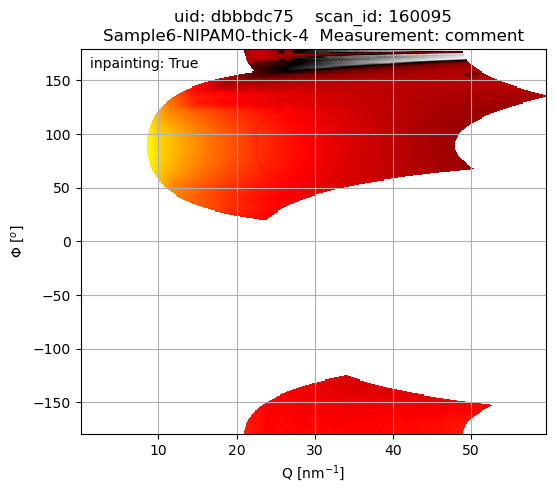

In [11]:
inpainting = True # paint in detector mask gaps before creating phi_map
phi_unit="q_nm^-1"

if select_frame_range:
    img_average_phi = ave_img
else: img_average_phi = ave_img_mod

print('using inpainting for phi-map: %s'%inpainting)

if inpainting:
    quadrant_mask = np.zeros(np.shape(mask))
    quadrant_mask[0:423,487:]=1
    infill_mask=quadrant_mask+corner_mask+platform_mask#+flare_mask
    ind=infill_mask>.1;infill_mask[ind]=1
    ind = infill_mask==np.nan
    infill_mask[ind]=1
    d2_img = aintegrator.inpainting(img_average_phi, mask=mask_, poissonian=True) 
    d2_mask = corner_mask+quadrant_mask
else:
    d2_img=yim
    d2_mask = mask_

mmethod=[]
for m in IntegrationMethod.select_method(dim=2):
    mmethod.append(m)
method = mmethod[3] 
phi_map=aintegrator.integrate2d(d2_img, npt_rad=1200, npt_azim=360,mask=d2_mask,unit=phi_unit, method=method,polarization_factor=1) #_legacy gets the old behavior with large gaps or method[3,4]
process_dict['phi_map']['data']={'intensity':phi_map[0],'q':phi_map[1],'Phi':phi_map[2]};process_dict['phi_map']['units']={'q':phi_unit,'phi':'$\Phi$ [$^o$]'}
process_dict['processing']['phi_map_inpainitng']=inpainting;process_dict['processing']['phi_map_method']=str(method)

fig,ax = plt.subplots(figsize=(6,5))
plt.imshow(phi_map[0],norm='log',extent=[phi_map[1][0], phi_map[1][-1], phi_map[2][0],phi_map[2][-1]],cmap=cmap_albula)
ax=plt.gca()
ax.set_aspect('auto')
plt.xlabel('Q [nm$^{-1}$]');plt.ylabel('$\Phi$ [$^o$]')
plt.title('uid: %s    scan_id: %s\n%s  Measurement: %s'%(uid_list[0],h.start['scan_id'],h.start['sample'],h.start['Measurement']))
plt.text(0.02, .98, 'inpainting: %s'%inpainting, horizontalalignment='left',verticalalignment='top', transform=ax.transAxes)
plt.grid(True,'both')

### Save Data

In [ ]:
if True:
    include_samplename_in_filename = True
    try:
        data_dir = os.path.join(result_dir, '%s/'%process_dict['md']['uid'])
        os.makedirs(data_dir, exist_ok=True)
        fn='waxs_processed_uid=%s.pkl'%process_dict['md']['uid']
        save_pickle(data_dir+fn,process_dict)
        print('Successfully saved the processed WAXS data as %s!'%(data_dir+fn))
    except:
        print('ERROR: failed to save the processed WAXS data!')
else:
    print('WARNING: processed WAXS data has NOT been saved!')

### Export Data in some custom formats

In [ ]:
export_1D_average = True
export_2D_average = True
export_phi_map = True

if True:
    include_samplename_in_filename = True
    if include_samplename_in_filename:
            sample_name = '_'+sanitize_filename(process_dict['md']['sample'])
            max_filename_length = os.pathconf('/','PC_NAME_MAX')
            sample_name = sample_name[:max_filename_length-50]
    else:
        sample_name=''
    import pandas as pd # only import pandas if we actually need it
    # we load the processed WAXS data and save from there -> assert that the .pkl file containing all information and the exported files are 'in sync'
    try:
        full_uid = db[uid_list[0]].start['uid']
        data_dir = os.path.join(result_dir, '%s/'%full_uid)
        fn='waxs_processed_uid=%s.pkl'%full_uid
        process_dict = load_pickle(data_dir+fn)
        print('Successfully loaded processed data from %s\n'%(data_dir+fn))
    except:
        raise Exception('ERROR: failed to load processed WAXS data from %s -> can NOT export data!\n'%(data_dir+fn))
    
    ### exporting data in custom formats:
    export_dict={};process_dict['processing']['file_export']={}
    if  'frame_list' in process_dict['processing']:
        dd='_range'
    else:
        dd='_all'
    export_dict={'1D%s_average'%dd:export_1D_average,'2D%s_average'%dd:export_2D_average,'phi_map':export_phi_map}
    for k in export_dict.keys():
        if '1D' in k and 'average' in k and export_dict[k]: # exporting 1D averaged data
            try:
                dfn = pd.DataFrame({"q":process_dict[k]['data']['q'], "iq_waxs":process_dict[k]['data']['iq_waxs']})
                fnn=data_dir+"1D_average%s_scan_%s.csv"%(sample_name,process_dict['md']['scan_id'])
                dfn.to_csv(fnn, index = False, header = ['q','iq_waxs'])
                print('Successfully exported 1D averaged data as %s!\n'%fnn)
                process_dict['processing']['file_export'][k]={'filename':fnn,'export time':str(datetime.fromtimestamp(time.time()))}
            except:
                print('WARNING: failed to export 1D averaged data!\n')
        if '2D' in k and 'average' in k and export_dict[k]: # exporting 2D averaged data
            try:
                dfn = pd.DataFrame(process_dict[k]['img'])
                fnn=data_dir+"2D_average%s_scan_%s.csv"%(sample_name,process_dict['md']['scan_id'])
                dfn.to_csv(fnn, index = False)
                print('Successfully exported 2D averaged data as %s!\n'%fnn)
                process_dict['processing']['file_export'][k]={'filename':fnn,'export time':str(datetime.fromtimestamp(time.time()))}
            except:
                print('WARNING: failed to export 2D averaged data!\n')
        if 'phi' in k and export_dict[k]: # exporting phi map
            try:
                fnn=data_dir+"phi_map%s_scan_%s.csv"%(sample_name,process_dict['md']['scan_id'])
                dfn = pd.DataFrame(process_dict['phi_map']['data']['intensity'],index=process_dict['phi_map']['data']['Phi'],columns=process_dict['phi_map']['data']['q'])
                dfn.to_csv(fnn)
                print('Successfully exported Q-Phi map %s!\n'%fnn)
                process_dict['processing']['file_export'][k]={'filename':fnn,'export time':str(datetime.fromtimestamp(time.time()))}
            except:
                print('WARNING: failed to export Q-Phi map!\n')
    save_pickle(data_dir+fn,process_dict)
    print('Saved processed WAXS data with updated information about file exports.')
else:
    print('NOTE: no files have been exported...')